# Imports and Config

In [1]:
import os
import matplotlib.pyplot as plt
from grf_pipeline_utils.signal_processing import *
from grf_pipeline_utils.opensim_utils import *
from grf_pipeline_utils.data_utils import *
import pickle
import yaml

repo_root     = os.path.abspath('../')
with open(os.path.join(repo_root, 'config.yaml')) as f:
    cfg = yaml.safe_load(f)

processed_dir  = os.path.join(repo_root, cfg['silder']['results']['processed'])
grf_pickle_dir = os.path.join(processed_dir, 'grf_pickles')
so_dir         = os.path.join(repo_root, cfg['silder']['results']['so'])
jrf_dir        = so_dir
out_dir        = processed_dir

OA_masses = cfg['silder']['OA_masses']
Y_masses  = cfg['silder']['Y_masses']
subj_masses = OA_masses + Y_masses

skip_subjects = set(cfg['silder']['skip_subjects'])


# Import all segmented gait data

Load the pre-computed `all_segs` dictionary from disk. `all_segs` is a nested structure keyed by subject ID, where each subject maps trial names to a dict of `'left'` and `'right'` lists of `(start_time, end_time)` tuples identifying individual stance-phase gait cycles detected during preprocessing. The following cell counts the total number of left and right foot contacts across all subjects and trials.

In [2]:
with open(os.path.join(processed_dir, 'all_stance_segs.pkl'), 'rb') as f:
    all_segs = pickle.load(f)
print(all_segs)


{'OA1': {'OA1_80_1': {'left': [(1.2885, 2.0735)], 'right': [(0.6945, 1.475), (1.886, 2.696)]}, 'OA1_80_2': {'left': [(1.207, 2.011)], 'right': [(0.6065, 1.4145), (1.824, 2.6345)]}, 'OA1_80_3': {'left': [(1.151, 1.9685)], 'right': [(0.543, 1.357), (1.778, 2.577)]}, 'OA1_80_4': {'left': [(1.232, 2.0545)], 'right': [(0.624, 1.433), (1.8555, 2.689)]}, 'OA1_80_5': {'left': [(1.0405, 1.837)], 'right': [(0.4395, 1.2235), (1.652, 2.4615)]}, 'OA1_100_1': {'left': [(0.912, 1.6125)], 'right': [(0.37, 1.072), (1.4565, 2.1605)]}, 'OA1_100_2': {'left': [(1.0515, 1.741)], 'right': [(0.5325, 1.214), (1.5905, 2.278)]}, 'OA1_100_3': {'left': [(0.978, 1.6435)], 'right': [(0.476, 1.1395), (1.502, 2.178)]}, 'OA1_100_4': {'left': [(0.551, 1.1595), (1.5375, 2.1985)], 'right': [(1.0135, 1.698)]}, 'OA1_100_5': {'left': [(0.8995, 1.5655)], 'right': [(0.385, 1.061), (1.418, 2.1145)]}, 'OA1_120_1': {'left': [(0.9025, 1.513)], 'right': [(0.409, 1.0285)]}, 'OA1_120_2': {'left': [(0.7965, 1.4055)], 'right': [(0.347,

In [3]:
left = 0
right = 0
for subjects, trials in all_segs.items():
    for trial_data in trials.values():
        left += len(trial_data['left'])
        right += len(trial_data['right'])
print(f'{left} left foot segments')
print(f'{right} right foot segments')
print(f'{left + right} segments total')

801 left foot segments
842 right foot segments
1643 segments total


# Extract Muscle Force Segments 

Call `data_to_segs` to iterate over every subject and trial in `all_segs`, load the corresponding GRF pickle and Static Optimization (SO) `.sto` results file, and slice each signal into stance-phase segments using the heel-strike/toe-off time windows found in 'all_segs'. Both right and left limbs are handled, with the medial-lateral GRF sign flipped for left-side contacts. An optional Achilles force channel is computed as the sum of gastrocnemius lateralis, gastrocnemius medialis, and soleus. Segments flagged in `problem_seg_keys` are skipped. The output `all_muscle_segs` is a subject-keyed dict of signal-keyed segment lists.

In [8]:
muscles = [
    "addbrev_r", "addlong_r", "addmagDist_r", "addmagIsch_r", "addmagMid_r", "addmagProx_r",
    "bflh_r", "bfsh_r", "edl_r", "ehl_r", "fdl_r", "fhl_r", "gaslat_r", "gasmed_r",
    "glmax1_r", "glmax2_r", "glmax3_r", "glmed1_r", "glmed2_r", "glmed3_r",
    "glmin1_r", "glmin2_r", "glmin3_r", "grac_r", "iliacus_r", "perbrev_r", "perlong_r",
    "psoas_r", "recfem_r", "semimem_r", "semiten_r", "soleus_r",
    "tibant_r", "tibpost_r", "vasint_r", "vaslat_r", "vasmed_r",

    "addbrev_l", "addlong_l", "addmagDist_l", "addmagIsch_l", "addmagMid_l", "addmagProx_l",
    "bflh_l", "bfsh_l", "edl_l", "ehl_l", "fdl_l", "fhl_l", "gaslat_l", "gasmed_l",
    "glmax1_l", "glmax2_l", "glmax3_l", "glmed1_l", "glmed2_l", "glmed3_l",
    "glmin1_l", "glmin2_l", "glmin3_l", "grac_l", "iliacus_l", "perbrev_l", "perlong_l",
    "psoas_l", "recfem_l", "semimem_l", "semiten_l", "soleus_l",
    "tibant_l", "tibpost_l", "vasint_l", "vaslat_l", "vasmed_l"
]
problem_trials = []


jrf_filename = 'results_JointReaction_JointRxn_ReactionLoads.sto'

jrf_col_map = {
    # output key             right-side column                                    left-side column
    'knee_fx':  {'r': 'walker_knee_r_on_tibia_r_in_tibia_r_fx',         'l': 'walker_knee_l_on_tibia_l_in_tibia_l_fx'},
    'knee_fy':  {'r': 'walker_knee_r_on_tibia_r_in_tibia_r_fy',         'l': 'walker_knee_l_on_tibia_l_in_tibia_l_fy'},
    'knee_fz':  {'r': 'walker_knee_r_on_tibia_r_in_tibia_r_fz',         'l': 'walker_knee_l_on_tibia_l_in_tibia_l_fz'},
    'ankle_fx': {'r': 'ankle_r_on_talus_r_in_talus_r_fx',               'l': 'ankle_l_on_talus_l_in_talus_l_fx'},
    'ankle_fy': {'r': 'ankle_r_on_talus_r_in_talus_r_fy',               'l': 'ankle_l_on_talus_l_in_talus_l_fy'},
    'ankle_fz': {'r': 'ankle_r_on_talus_r_in_talus_r_fz',               'l': 'ankle_l_on_talus_l_in_talus_l_fz'},
}

all_muscle_segs, problematic_force_segs = data_to_segs(
    muscles=muscles,
    seg_times=all_segs,
    problem_trials=problem_trials,
    grf_pickle_dir= grf_pickle_dir,
    muscle_force_dir=so_dir,
    problematic_seg_keys=[],
    jrf_dir=jrf_dir,
    jrf_filename=jrf_filename,
    jrf_col_map=jrf_col_map,
)

n_segs = sum(
    len(subj_data["grf_y"])
    for subj_data in all_muscle_segs.values()
)
print(n_segs, 'gait cycles')


1643 gait cycles


# Resample Segments to a Common Time Grid

Interpolate every segment for every signal and subject onto a fixed 100-point time grid using `interp_segments`. The result `resampled_segs` mirrors the structure of `all_muscle_segs` but with uniform-length arrays, enabling straightforward stacking and averaging across trials. A shared `'time_resampled'` key is appended to the dict for use as the x-axis in downstream plots.

In [9]:
n_interp_points = 100
resampled_segs = {}

for subj, subj_data in all_muscle_segs.items():
    resampled_segs[subj] = {}
    for key, seg_list in subj_data.items():
        if len(seg_list) == 0:
            resampled_segs[subj][key] = []
            continue 
        resampled, time_resampled = interp_segments(seg_list, n_interp_points)
        resampled_segs[subj][key] = resampled
resampled_segs['time_resampled'] = time_resampled

# Normalize Forces by Body Mass

Divide all muscle forces by each subject's body mass (kg) to produce body-mass-normalized forces (N/kg), making comparisons across subjects and between the OA and young-adult (YA) cohorts more meaningful. Subject masses are listed in the same order as the subjects in `resampled_segs`. The normalized output is stored in `normalized_muscle_segs`.

In [10]:
base_muscles = sorted({m[:-2] for m in muscles if m.endswith(("_r", "_l"))})
base_muscles.append('achilles')

base_jrfs = list(jrf_col_map.keys())

normalizer_keys = base_muscles + base_jrfs + ['grf_x', 'grf_y', 'grf_z']
normalized_segs = normalize_by_mass_in_order(resampled_segs, subj_masses, normalizer_keys)


# Filter out trials that are consistently/extremely out of distribution

In [24]:
# Run Mean +/- 2 std and RMS filter 
# mode  : 'any' drops a segment if ANY muscle is flagged (strict)
#          use 'all' for a more lenient filter
consistency_mode = 'any'
rms_threshold = 0.75
mean_threshold = 0.3

filter_keys = base_muscles + base_jrfs + ['grf_x', 'grf_y', 'grf_z', 'cop_x']

normalized_segs_filtered, dropped, bands = filter_segments(
    seg_dict=normalized_segs,
    muscle_keys=filter_keys,
    consistency_mode=consistency_mode,
    rms_threshold=rms_threshold,
    mean_threshold=mean_threshold,
)

# Summary 
n_before = sum(
    len(data.get('achilles', []))
    for data in normalized_segs.values()
    if isinstance(data, dict)
)
n_after = sum(
    len(data.get('achilles', []))
    for data in normalized_segs_filtered.values()
    if isinstance(data, dict)
)
print(f'Segments before MAD filter : {n_before}')
print(f'Segments after  MAD filter : {n_after}')
print(f'Dropped                    : {len(dropped)} ({100*len(dropped)/n_before:.1f}%)')

# Which muscles triggered the most drops?
from collections import Counter
c = Counter()
for _, _, bad_muscles in dropped:
    c.update(bad_muscles)
print('\nTop muscles triggering drops:')
for muscle, count in c.most_common(10):
    print(f'  {muscle:<20} {count}')

Segments before MAD filter : 1643
Segments after  MAD filter : 1018
Dropped                    : 625 (38.0%)

Top muscles triggering drops:
  recfem               144
  grf_y                123
  iliacus              113
  psoas                109
  grf_x                105
  knee_fy              104
  vaslat               101
  knee_fx              101
  gasmed               85
  addlong              85


# Plot Segmented GRF Data

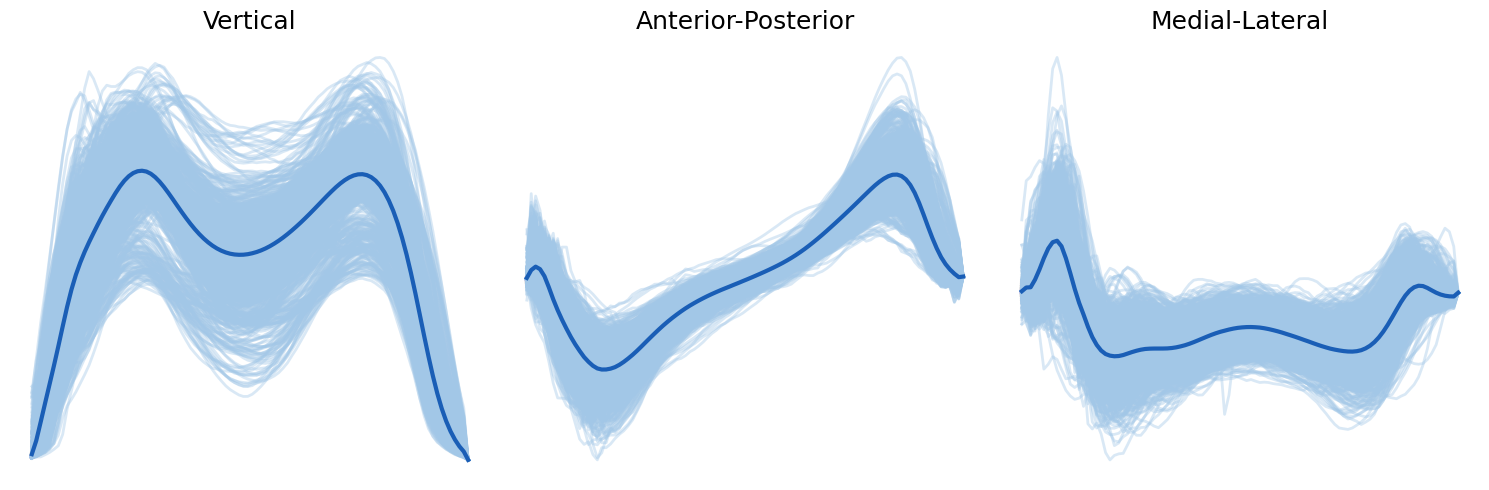

In [25]:
grf_y_resampled = get_all_segments(normalized_segs_filtered, 'grf_y')
time_resampled = normalized_segs_filtered['time_resampled']
grf_x_resampled = get_all_segments(normalized_segs_filtered, 'grf_x')
time_resampled = normalized_segs_filtered['time_resampled']
grf_z_resampled = get_all_segments(normalized_segs_filtered, 'grf_z')
time_resampled = normalized_segs_filtered['time_resampled']
# Stack into arrays
grf_y = np.array(grf_y_resampled)
grf_x = np.array(grf_x_resampled)
grf_z = np.array(grf_z_resampled)
time = time_resampled[0] * 100  # percent stance

# Set up 3-column subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# Define GRF components
components = [
    ("Vertical", grf_y),
    ("Anterior-Posterior", grf_x),
    ("Medial-Lateral", grf_z)
]

colors = {
    'fill': '#5190E4',
    'line': '#1A5EB6'
}
num_grf_segments = len(grf_y_resampled)
for ax, (label, grf_array) in zip(axes, components):
    mean_grf = np.mean(grf_array, axis=0)
    
    for i in range(num_grf_segments):
        ax.plot(time, grf_array[i], linewidth=2, color="#A2C7E7", alpha=0.4)

    # Mean line
    ax.plot(time, mean_grf, color=colors['line'], linewidth=3, label='Mean GRF')
    
    ax.set_title(f"{label}", fontsize=18)
    ax.set_xlabel("Percent Normalized Stance (%)", fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_axis_off()
    # ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Ground Reaction Force (N)", fontsize=16)
# axes[0].legend(fontsize=12)

plt.tight_layout()
plt.show()

# Plot COP Data

(array([-0.025,  0.   ,  0.025,  0.05 ,  0.075,  0.1  ,  0.125,  0.15 ,
         0.175,  0.2  ]),
 [Text(0, -0.025, '−0.025'),
  Text(0, 0.0, '0.000'),
  Text(0, 0.025, '0.025'),
  Text(0, 0.05000000000000001, '0.050'),
  Text(0, 0.07500000000000001, '0.075'),
  Text(0, 0.1, '0.100'),
  Text(0, 0.12500000000000003, '0.125'),
  Text(0, 0.15000000000000002, '0.150'),
  Text(0, 0.17500000000000002, '0.175'),
  Text(0, 0.2, '0.200')])

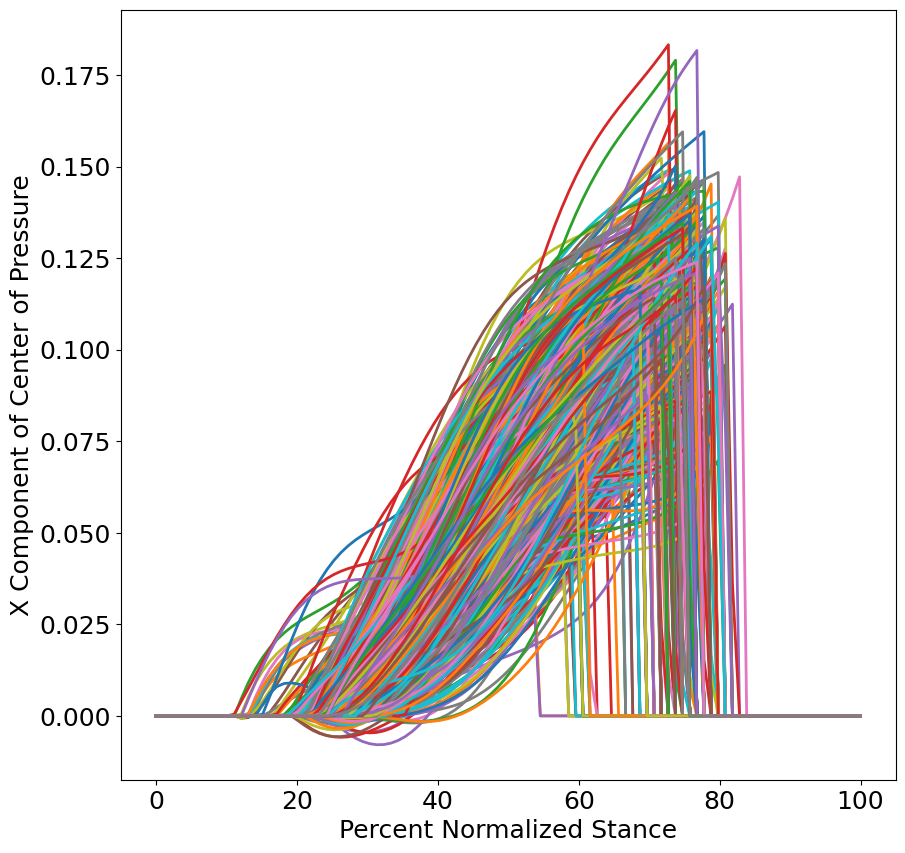

In [26]:
cop_x_resampled = get_all_segments(normalized_segs_filtered, 'cop_x')
time_resampled = normalized_segs_filtered['time_resampled']
figure = plt.figure(figsize=(10, 10))

num_cop_segments = len(cop_x_resampled)

for i in range(num_cop_segments):
    plt.plot(time_resampled[0] * 100, cop_x_resampled[i], linewidth=2)

plt.ylabel("X Component of Center of Pressure", fontsize=18)
plt.xlabel("Percent Normalized Stance", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.xlim([0, 1])
# plt.ylim([0, 1200])

# Plot Muscle Forces

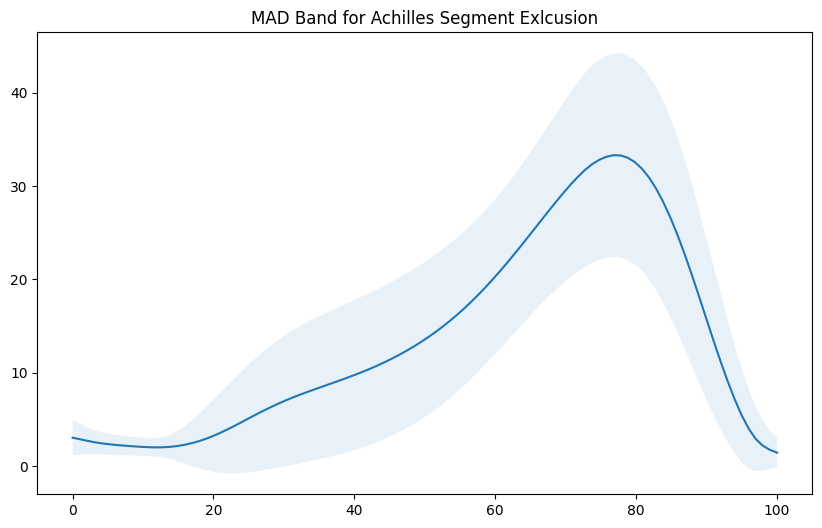

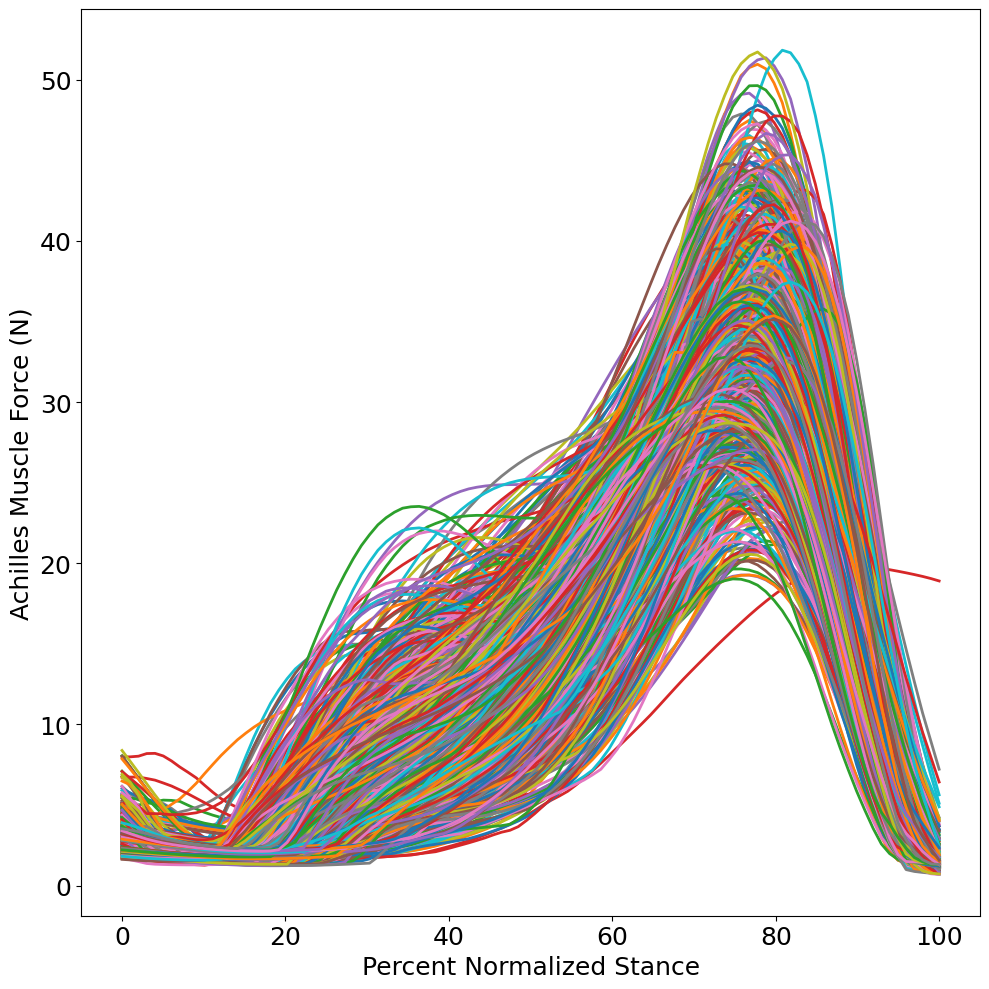

In [27]:
achilles_resampled = get_all_segments(normalized_segs_filtered, 'achilles')
mean_achilles  = np.mean(achilles_resampled, axis=0)
std_achilles = np.std(achilles_resampled, axis=0)


lo = mean_achilles - 2 * std_achilles
hi = mean_achilles + 2 * std_achilles
for seg in achilles_resampled:
    outside = (seg < lo) | (seg > hi)
    
plt.figure(figsize=(10, 6))
t = np.linspace(0, 100, achilles_resampled.shape[1])
plt.fill_between(t, lo, hi, alpha = 0.1)
plt.plot(t, mean_achilles)
plt.title('MAD Band for Achilles Segment Exlcusion')

plot_achilles_segments(achilles_resampled, time_resampled)

# Plot Filtered Muscle Forces

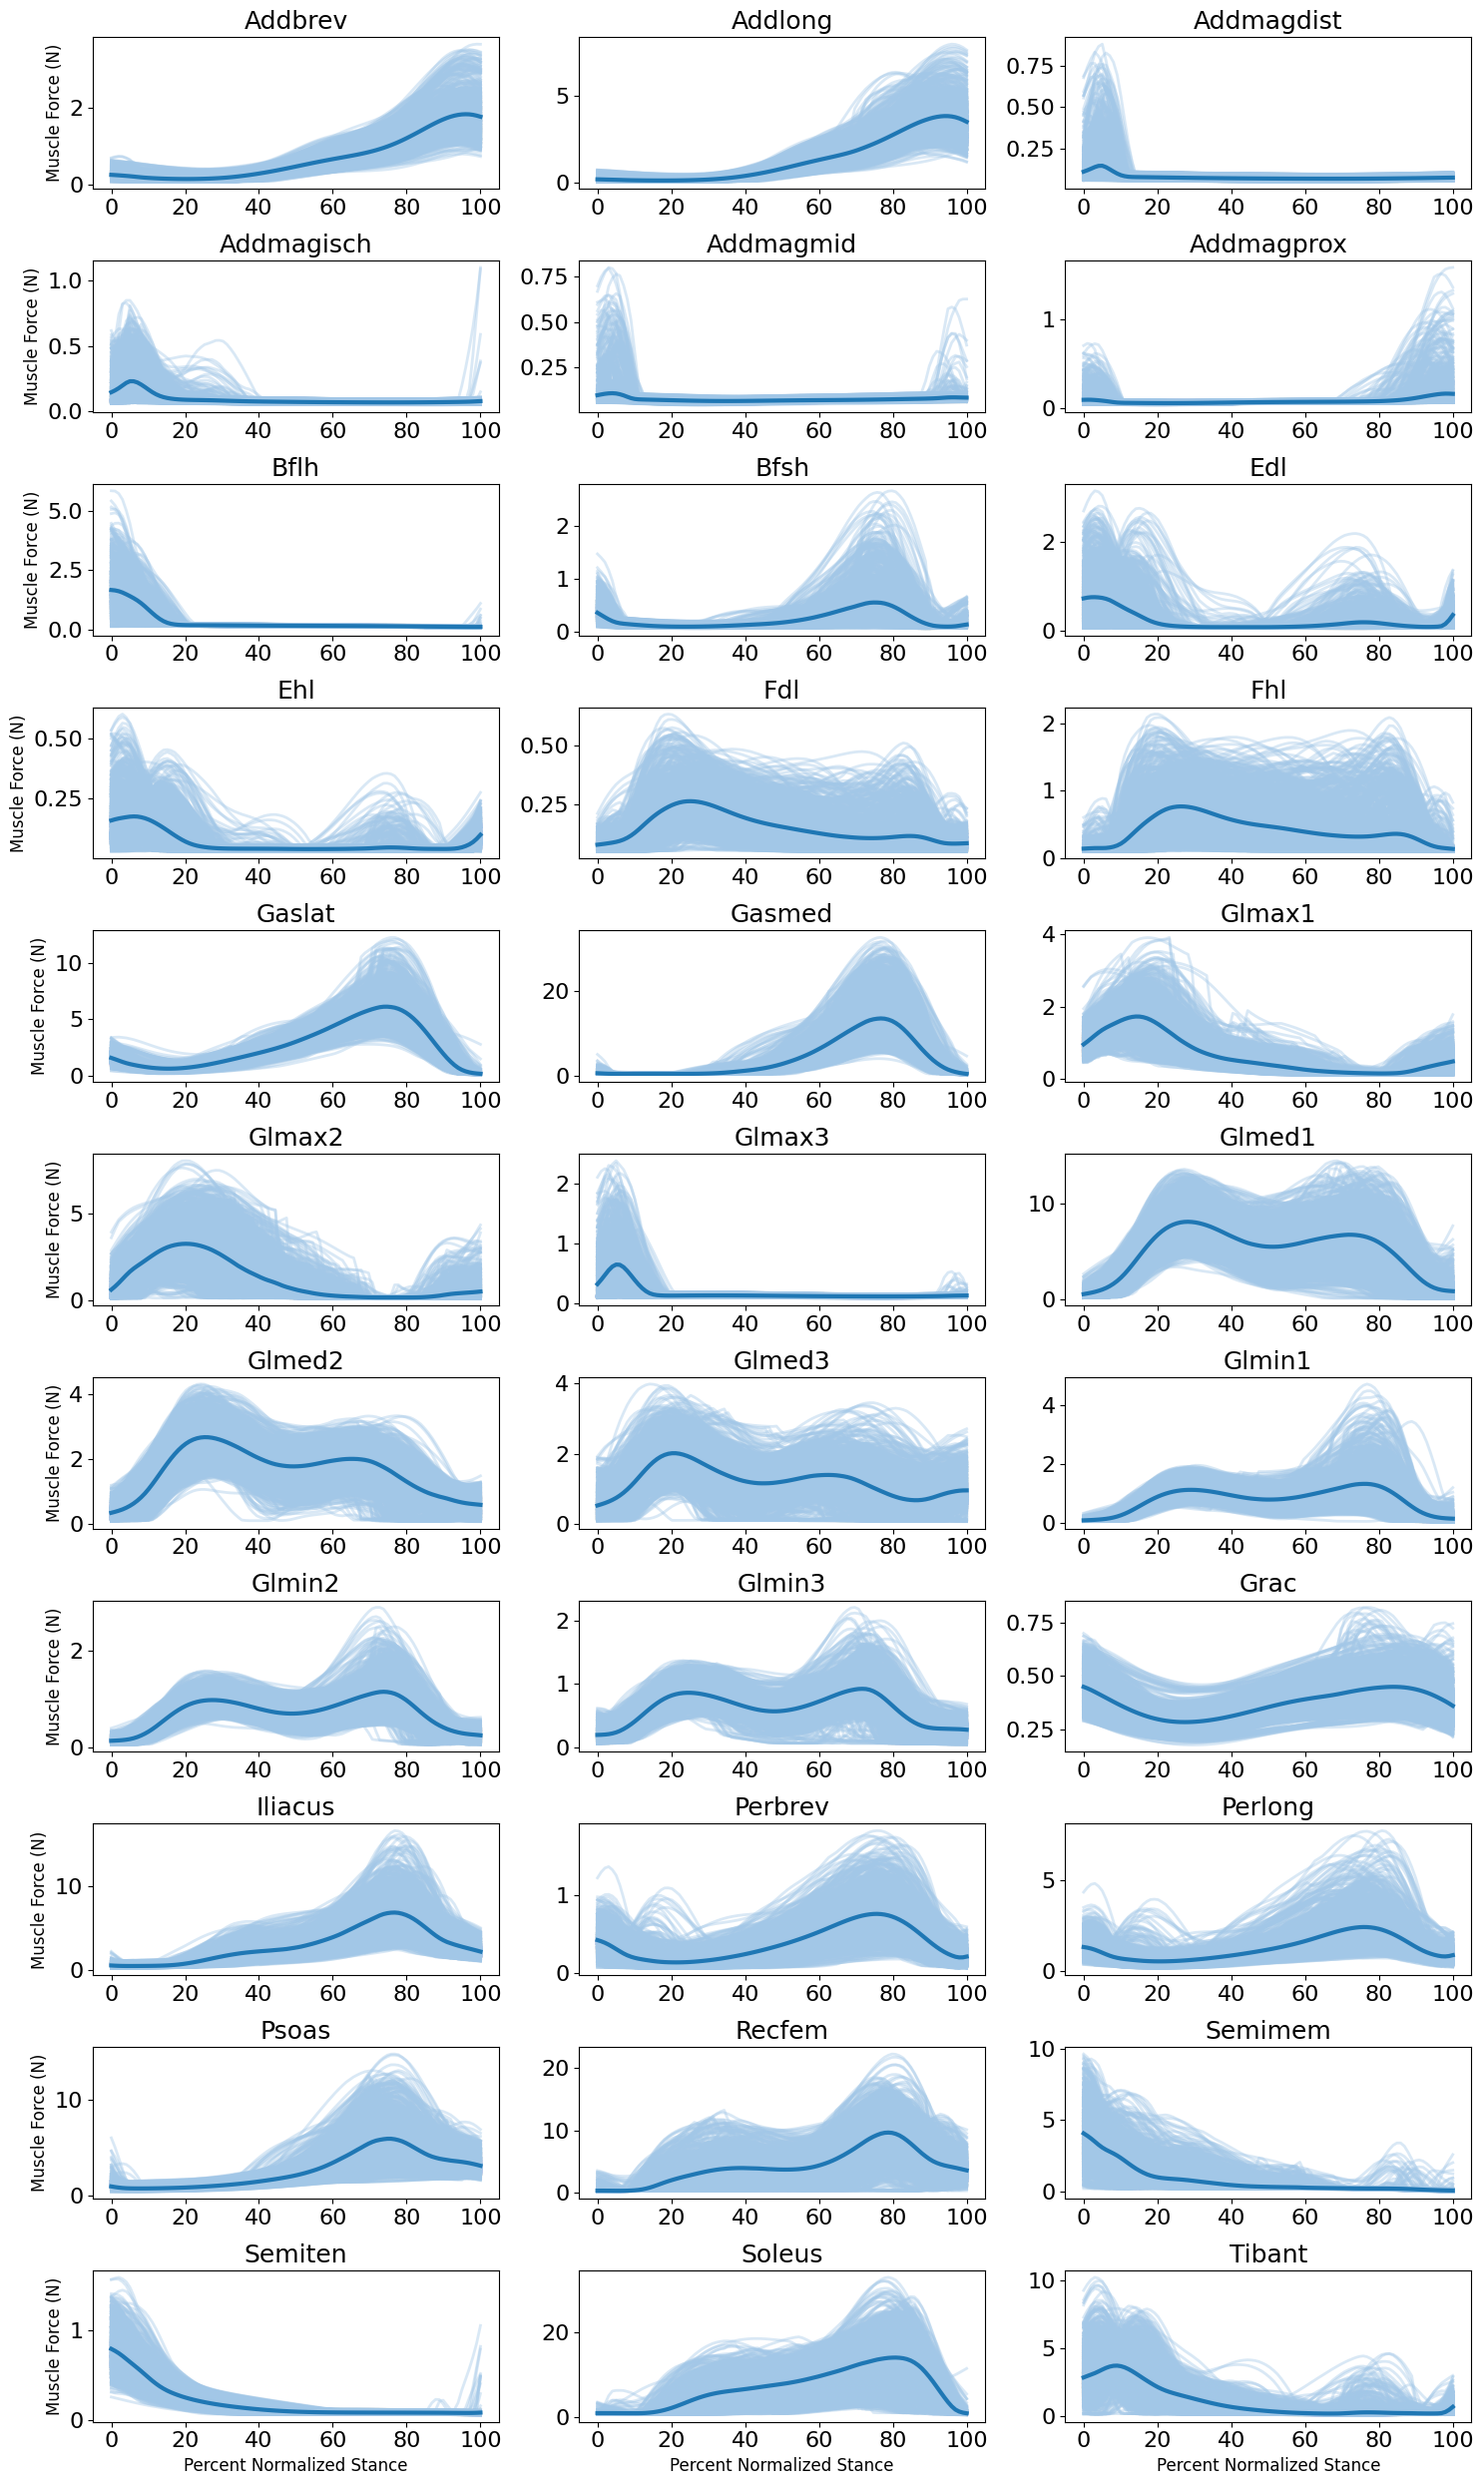

In [28]:
resampled_filtered_muscles = flatten_to_muscle_dict(normalized_segs_filtered, base_muscles)

plot_muscle_grid(
    resampled_filtered_muscles,
    time_resampled,
    base_muscles,
    plot_mean=True
)

# Plot Filtered Joint Contact Forces

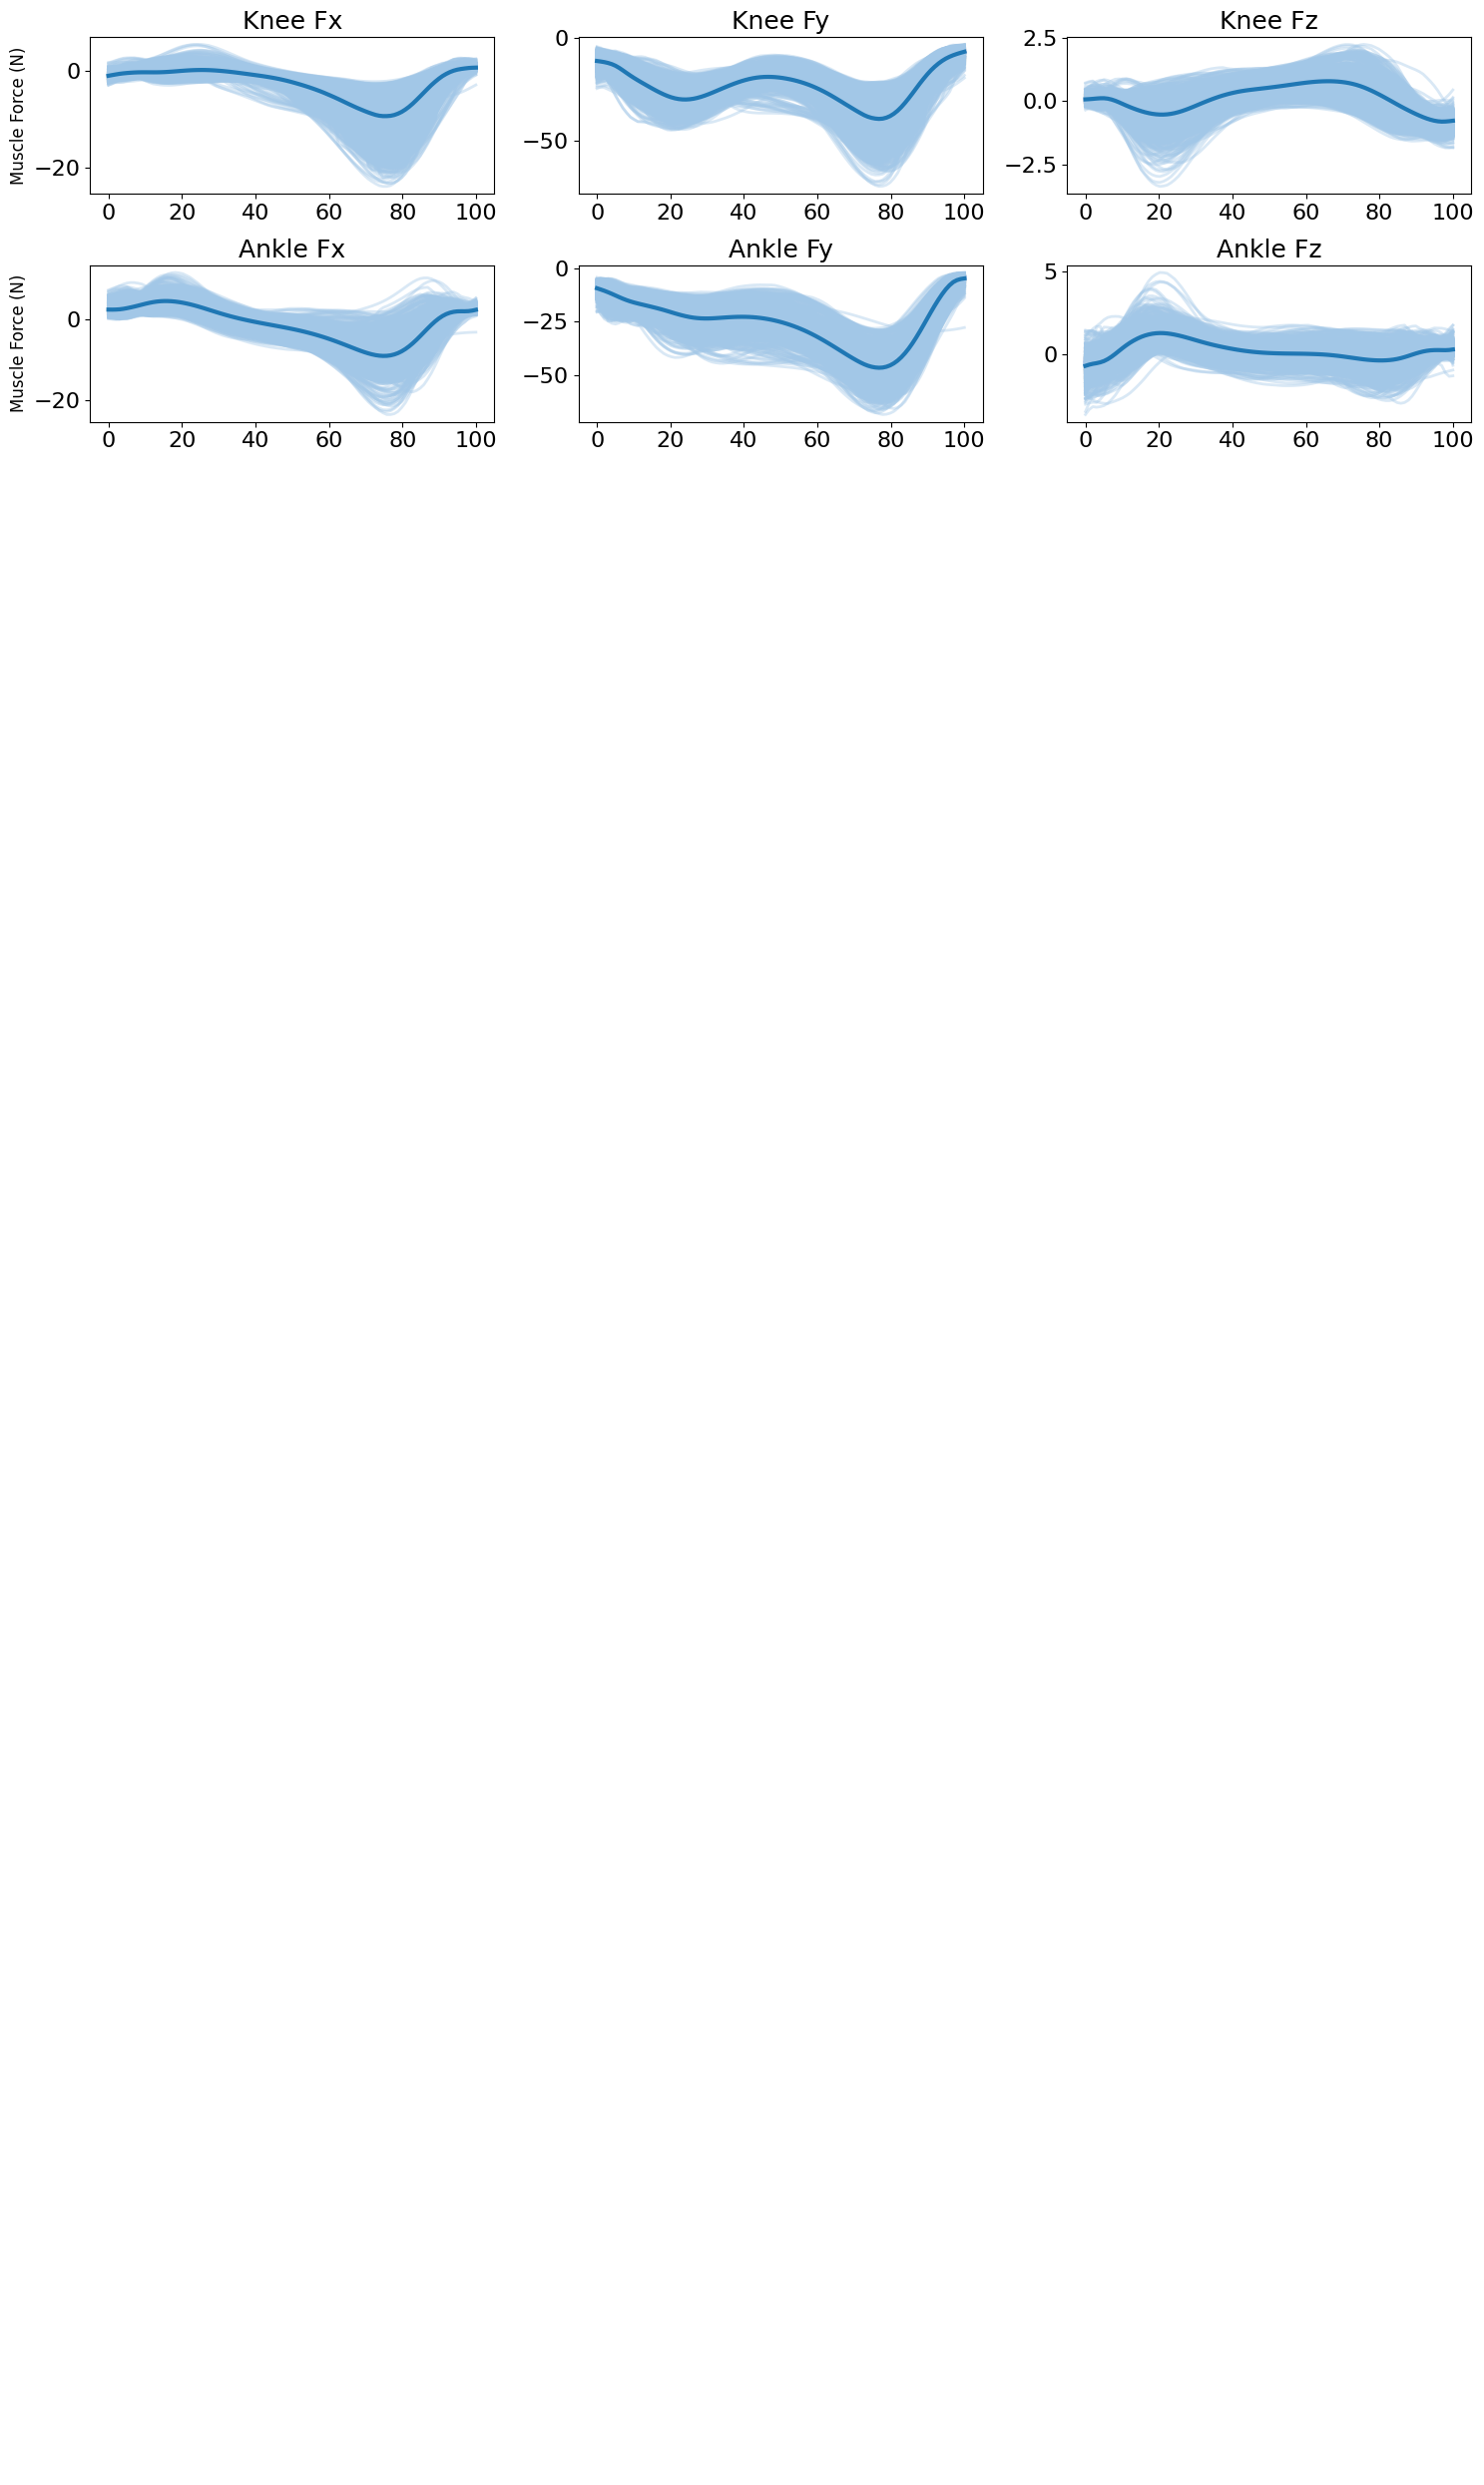

In [29]:
resampled_filtered_jrfs = flatten_to_muscle_dict(normalized_segs_filtered, base_jrfs)

plot_muscle_grid(
    resampled_filtered_jrfs,
    time_resampled,
    base_jrfs,
    plot_mean=True
)

# Plot Unfiltered Muscle Forces

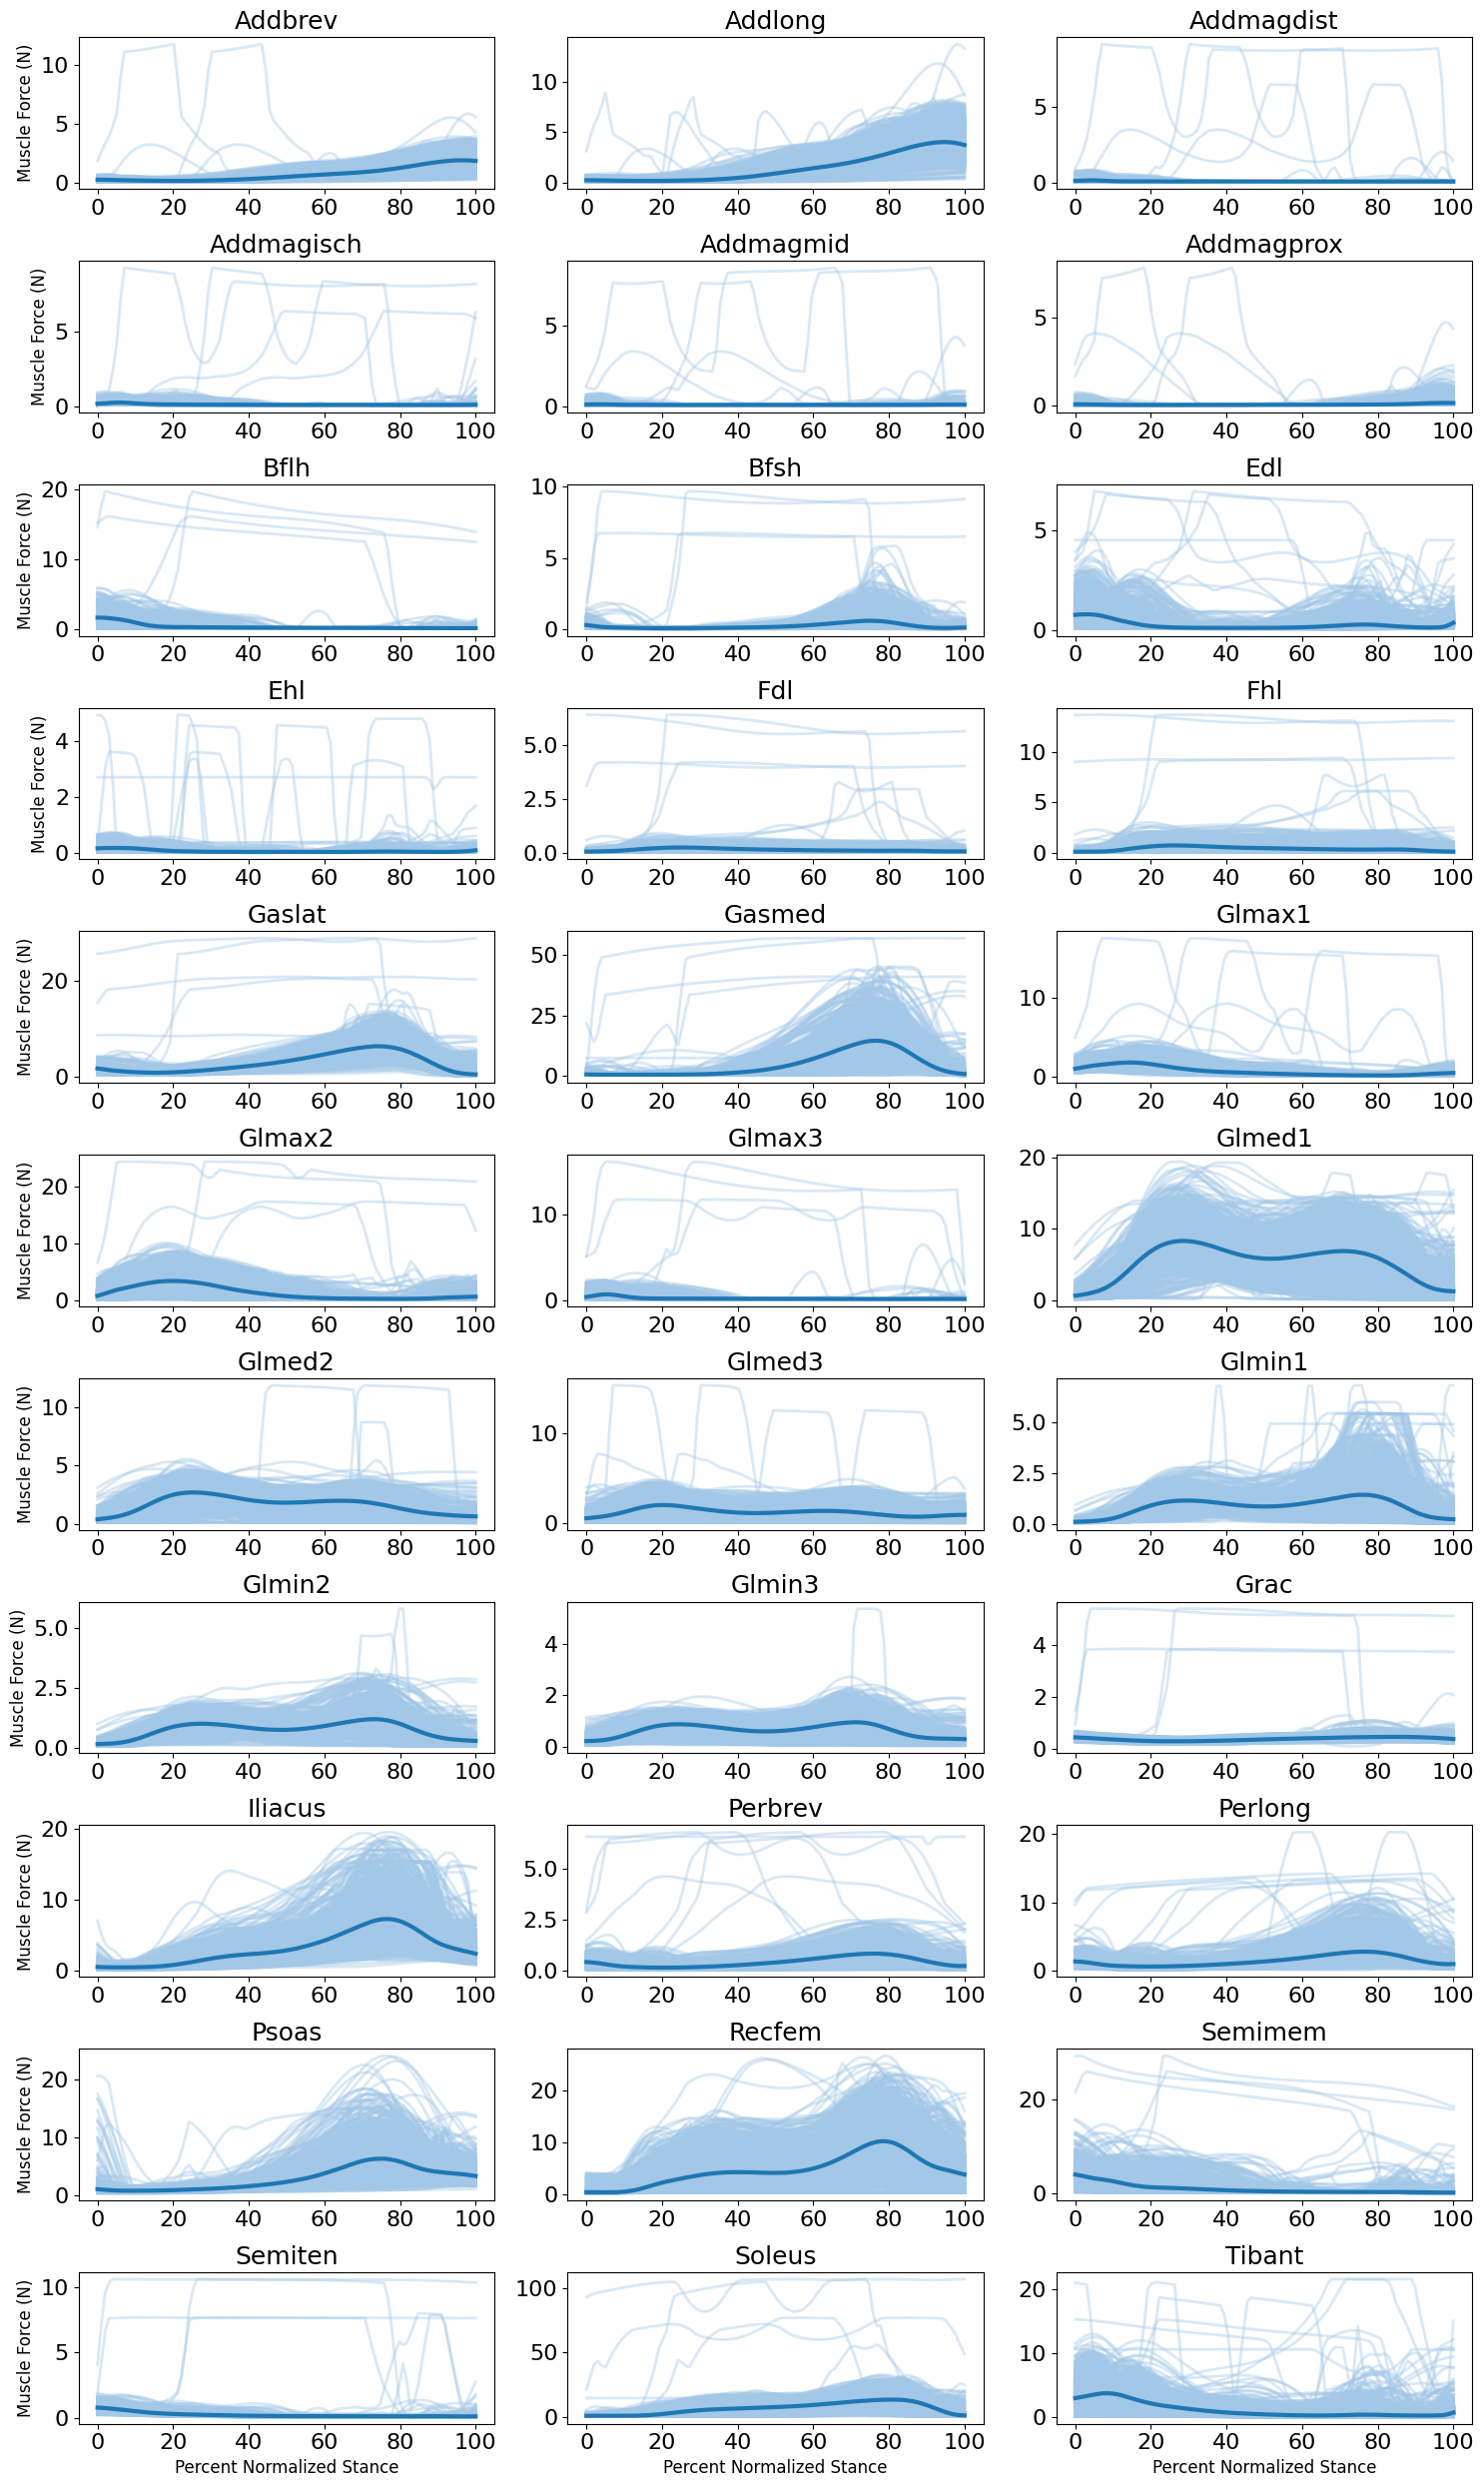

In [21]:
resampled_muscles = flatten_to_muscle_dict(normalized_segs, base_muscles)

plot_muscle_grid(
    resampled_muscles,
    time_resampled,
    base_muscles,
    plot_mean=True
)

# Split into OA and YA Cohorts

Split `normalized_segs_filtered` into separate dicts by cohort prefix (`"OA"` vs `"Y"`), preserving the shared `'time_resampled'` key in both. These can then be exported and mixed with external YA datasets for cross-dataset model training experiments.

In [30]:
OA_segs = {k: v for k, v in normalized_segs_filtered.items() if isinstance(k, str) and k.startswith('OA')}
YA_segs = {k: v for k, v in normalized_segs_filtered.items() if isinstance(k, str) and k.startswith('Y')}

# Carry over the shared time axis
OA_segs['time_resampled'] = normalized_segs_filtered['time_resampled']
YA_segs['time_resampled'] = normalized_segs_filtered['time_resampled']

print(f"OA subjects : {len(OA_segs) - 1}")   # -1 for time_resampled key
print(f"YA subjects : {len(YA_segs) - 1}")

# Segment counts
oa_n = sum(len(v.get('grf_y', [])) for v in OA_segs.values() if isinstance(v, dict))
ya_n = sum(len(v.get('grf_y', [])) for v in YA_segs.values() if isinstance(v, dict))
print(f"OA segments : {oa_n}")
print(f"YA segments : {ya_n}")

OA subjects : 19
YA subjects : 21
OA segments : 531
YA segments : 487


## Per-Subject Contents Summary

Print the keys available and segment count for each subject in both cohorts.

In [31]:
def print_cohort_summary(segs_dict, cohort_name):
    subj_keys = [k for k in segs_dict if isinstance(k, str) and k != 'time_resampled']
    print(f"{'='*60}")
    print(f"  {cohort_name}  ({len(subj_keys)} subjects)")
    print(f"{'='*60}")
    for subj in sorted(subj_keys):
        data = segs_dict[subj]
        n_segs = len(data.get('grf_y', []))
        signal_keys = sorted(data.keys())
        print(f"\n  {subj}:  {n_segs} segments")
        print(f"    signals ({len(signal_keys)}): {', '.join(signal_keys)}")
    print()

print_cohort_summary(OA_segs, "OA")
print_cohort_summary(YA_segs, "YA")

  OA  (19 subjects)

  OA1:  43 segments
    signals (50): achilles, addbrev, addlong, addmagDist, addmagIsch, addmagMid, addmagProx, ankle_fx, ankle_fy, ankle_fz, bflh, bfsh, cop_x, cop_y, cop_z, edl, ehl, fdl, fhl, gaslat, gasmed, glmax1, glmax2, glmax3, glmed1, glmed2, glmed3, glmin1, glmin2, glmin3, grac, grf_x, grf_y, grf_z, iliacus, knee_fx, knee_fy, knee_fz, perbrev, perlong, psoas, recfem, semimem, semiten, soleus, tibant, tibpost, vasint, vaslat, vasmed

  OA10:  31 segments
    signals (50): achilles, addbrev, addlong, addmagDist, addmagIsch, addmagMid, addmagProx, ankle_fx, ankle_fy, ankle_fz, bflh, bfsh, cop_x, cop_y, cop_z, edl, ehl, fdl, fhl, gaslat, gasmed, glmax1, glmax2, glmax3, glmed1, glmed2, glmed3, glmin1, glmin2, glmin3, grac, grf_x, grf_y, grf_z, iliacus, knee_fx, knee_fy, knee_fz, perbrev, perlong, psoas, recfem, semimem, semiten, soleus, tibant, tibpost, vasint, vaslat, vasmed

  OA11:  8 segments
    signals (50): achilles, addbrev, addlong, addmagDist, addmag

## Export OA and YA Segment Dicts

In [32]:
with open(os.path.join(out_dir, 'Silder_OA_segs_normalized_filtered'), 'wb') as f:
    pickle.dump(OA_segs, f)
print("Saved OA_segs_normalized_filtered")

with open(os.path.join(out_dir, 'Silder_YA_segs_normalized_filtered'), 'wb') as f:
    pickle.dump(YA_segs, f)
print("Saved YA_segs_normalized_filtered")

Saved OA_segs_normalized_filtered
Saved YA_segs_normalized_filtered
